In [2]:
# ============================================================
# CELL 1 — Install required libraries
# ============================================================

!pip -q install lime ucimlrepo

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
# ============================================================
# CELL 2 — Imports and configuration
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

from lime.lime_tabular import LimeTabularExplainer

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")
print("Random seed:", SEED)

Libraries imported successfully!
Random seed: 42


In [4]:
# ============================================================
# CELL 3 — Load Adult / Census Income Dataset
# ============================================================

print("Loading Adult / Census Income dataset...")

try:
    from ucimlrepo import fetch_ucirepo

    adult = fetch_ucirepo(id=2)

    X_raw = adult.data.features.copy()
    y_raw = adult.data.targets.copy()

    print("Dataset source: UCI Machine Learning Repository")

except Exception as e:
    print("UCI direct loading failed.")
    print("Using OpenML fallback...")

    from sklearn.datasets import fetch_openml

    adult = fetch_openml(
        name="adult",
        version=2,
        as_frame=True
    )

    X_raw = adult.data.copy()
    y_raw = pd.DataFrame({"income": adult.target})

    print("Dataset source: OpenML Adult dataset")

print("\nDataset loaded successfully!")
print("Shape:", X_raw.shape)

display(X_raw.head())

Loading Adult / Census Income dataset...
Dataset source: UCI Machine Learning Repository

Dataset loaded successfully!
Shape: (48842, 14)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [5]:
# ============================================================
# CELL 4 — Clean column names and target variable
# ============================================================

# Clean column names
X_raw.columns = [
    str(c).strip().replace("-", "_").replace(" ", "_")
    for c in X_raw.columns
]

# Extract target
target_col = y_raw.columns[0]

y = (
    y_raw[target_col]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

# Convert target to binary:
# 0 = <=50K
# 1 = >50K

y = y.str.lower().map({
    "<=50k": 0,
    ">50k": 1
})

# If mapping produced missing values, display the original values
if y.isna().any():
    print("Unexpected target values found:")
    print(y_raw[target_col].value_counts(dropna=False))
    raise ValueError("Target encoding failed.")

y = y.astype(int).to_numpy()

X = X_raw.copy()

print("Target variable:", target_col)
print("\nTarget classes:")
print(pd.Series(y).value_counts().sort_index())

display(X.head())

Target variable: income

Target classes:
0    37155
1    11687
Name: count, dtype: int64


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


In [6]:
# ============================================================
# CELL 5 — PART A, Q1: Dataset information
# ============================================================

numerical_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("=" * 60)
print("ADULT / CENSUS INCOME DATASET INFORMATION")
print("=" * 60)

print("Number of instances :", X.shape[0])
print("Number of features  :", X.shape[1])
print("Target variable     :", target_col)

print("\nFeature names:")
for i, feature in enumerate(X.columns, start=1):
    print(f"{i:2}. {feature}")

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features  :", len(numerical_features))
print("Number of categorical features:", len(categorical_features))

print("\nTarget encoding:")
print("0 = <=50K")
print("1 = >50K")

ADULT / CENSUS INCOME DATASET INFORMATION
Number of instances : 48842
Number of features  : 14
Target variable     : income

Feature names:
 1. age
 2. workclass
 3. fnlwgt
 4. education
 5. education_num
 6. marital_status
 7. occupation
 8. relationship
 9. race
10. sex
11. capital_gain
12. capital_loss
13. hours_per_week
14. native_country

Numerical features:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Categorical features:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Number of numerical features  : 6
Number of categorical features: 8

Target encoding:
0 = <=50K
1 = >50K


DATA QUALITY CHECKS

1. Missing values:
Total missing values: 2203


,Missing Values
occupation,966
workclass,963
native_country,274



2. Unknown / invalid categorical values represented by '?':


,Unknown '?' values
workclass,1836
occupation,1843
native_country,583



3. Duplicate records: 53

4. Class distribution:


,Class,Count,Percentage
0,<=50K,37155,76.07
1,>50K,11687,23.93


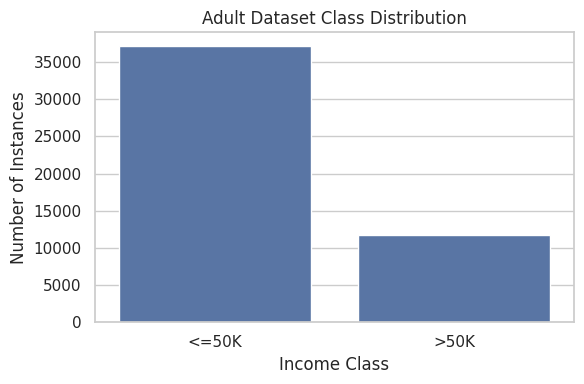

In [7]:
# ============================================================
# CELL 6 — PART A, Q2: Data quality checks
# ============================================================

print("=" * 60)
print("DATA QUALITY CHECKS")
print("=" * 60)

# Missing values
missing_values = X.isna().sum()

print("\n1. Missing values:")
print("Total missing values:", missing_values.sum())

if missing_values.sum() > 0:
    display(
        missing_values[missing_values > 0]
        .sort_values(ascending=False)
        .to_frame("Missing Values")
    )
else:
    print("No explicit NaN values found.")

# Check '?' values
question_mark_counts = {}

for col in categorical_features:
    count = (X[col].astype(str).str.strip() == "?").sum()
    if count > 0:
        question_mark_counts[col] = count

print("\n2. Unknown / invalid categorical values represented by '?':")

if question_mark_counts:
    display(pd.Series(question_mark_counts, name="Unknown '?' values"))
else:
    print("No '?' values found.")

# Duplicates
duplicate_count = X.duplicated().sum()

print("\n3. Duplicate records:", duplicate_count)

# Class imbalance
class_counts = pd.Series(y).value_counts().sort_index()
class_percentages = (
    pd.Series(y)
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

class_table = pd.DataFrame({
    "Class": ["<=50K", ">50K"],
    "Count": class_counts.values,
    "Percentage": class_percentages.values.round(2)
})

print("\n4. Class distribution:")
display(class_table)

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.xlabel("Income Class")
plt.ylabel("Number of Instances")
plt.title("Adult Dataset Class Distribution")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# CELL 7 — PART A, Q3 & Q4: Data preprocessing
# ============================================================

X_clean = X.copy()

# Convert '?' to NaN
for col in categorical_features:
    X_clean[col] = (
        X_clean[col]
        .astype(str)
        .str.strip()
        .replace("?", np.nan)
    )

# Numerical preprocessing:
# median imputation + standardization
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing:
# most-frequent imputation + one-hot encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")

print("\nNumerical preprocessing:")
print("  1. Median imputation")
print("  2. StandardScaler")

print("\nCategorical preprocessing:")
print("  1. Most-frequent imputation")
print("  2. One-hot encoding")
print("  3. Unknown categories ignored during transformation")

print("\nWhy categorical features require special handling in LIME:")
print("""
LimeTabularExplainer expects categorical variables to be represented
using integer category codes together with categorical_names.

Therefore, LIME will use a separate integer-coded representation of
the original categorical variables. The trained machine-learning
model can still use one-hot encoded data internally.

This prevents LIME from treating categorical values such as
education categories as continuous numerical quantities.
""")

Preprocessing pipeline created successfully.

Numerical preprocessing:
  1. Median imputation
  2. StandardScaler

Categorical preprocessing:
  1. Most-frequent imputation
  2. One-hot encoding
  3. Unknown categories ignored during transformation

Why categorical features require special handling in LIME:

LimeTabularExplainer expects categorical variables to be represented
using integer category codes together with categorical_names.

Therefore, LIME will use a separate integer-coded representation of
the original categorical variables. The trained machine-learning
model can still use one-hot encoded data internally.

This prevents LIME from treating categorical values such as
education categories as continuous numerical quantities.



In [9]:
# ============================================================
# CELL 8 — Create LIME-compatible feature representation
# ============================================================

# Make a copy
X_lime_source = X_clean.copy()

# Impute numerical values
for col in numerical_features:
    median_value = X_lime_source[col].median()
    X_lime_source[col] = X_lime_source[col].fillna(median_value)

# Impute categorical values
for col in categorical_features:
    mode_value = X_lime_source[col].mode()[0]
    X_lime_source[col] = X_lime_source[col].fillna(mode_value)

# Create integer codes for categorical features
category_mappings = {}

for col in categorical_features:
    categories = sorted(
        X_lime_source[col].astype(str).unique().tolist()
    )

    category_mappings[col] = categories

    mapping = {
        category: index
        for index, category in enumerate(categories)
    }

    X_lime_source[col] = (
        X_lime_source[col]
        .astype(str)
        .map(mapping)
        .astype(int)
    )

# Ensure numerical columns are numeric
for col in numerical_features:
    X_lime_source[col] = pd.to_numeric(
        X_lime_source[col],
        errors="coerce"
    )

# Fill any numerical conversion issues
X_lime_source[numerical_features] = (
    X_lime_source[numerical_features]
    .fillna(X_lime_source[numerical_features].median())
)

lime_feature_names = X_lime_source.columns.tolist()

# Categorical indices for LIME
categorical_indices = [
    lime_feature_names.index(col)
    for col in categorical_features
]

# categorical_names dictionary required by LIME
categorical_names = {
    lime_feature_names.index(col): category_mappings[col]
    for col in categorical_features
}

print("LIME-compatible representation created.")

print("\nNumber of LIME features:", len(lime_feature_names))

print("\nCategorical feature indices:")
print(categorical_indices)

print("\nExample categorical_names:")
for index, values in list(categorical_names.items())[:5]:
    print(index, ":", values[:10])

display(X_lime_source.head())

LIME-compatible representation created.

Number of LIME features: 14

Categorical feature indices:
[1, 3, 5, 6, 7, 8, 9, 13]

Example categorical_names:
1 : ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay', 'nan']
3 : ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors']
5 : ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']
6 : ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty']
7 : ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country
0,39,6,77516,9,13,4,0,1,4,1,2174,0,40,38
1,50,5,83311,9,13,2,3,0,4,1,0,0,13,38
2,38,3,215646,11,9,0,5,1,4,1,0,0,40,38
3,53,3,234721,1,7,2,5,0,2,1,0,0,40,38
4,28,3,338409,9,13,2,9,5,2,0,0,0,40,4


In [10]:
# ============================================================
# CELL 9 — PART B, Q5: Stratified train/test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Corresponding LIME representation
X_lime_train, X_lime_test, y_lime_train, y_lime_test = train_test_split(
    X_lime_source,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Training samples: 39073
Testing samples : 9769

Training class distribution:
0    0.76073
1    0.23927
Name: proportion, dtype: float64

Testing class distribution:
0    0.760672
1    0.239328
Name: proportion, dtype: float64


In [11]:
# ============================================================
# CELL 10 — PART B, Q6: Train classification models
# ============================================================

# Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced"
    ))
])

# Logistic Regression
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=SEED,
        class_weight="balanced"
    ))
])

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("Training Logistic Regression...")
lr_model.fit(X_train, y_train)

print("\nBoth models trained successfully!")

Training Random Forest...
Training Logistic Regression...

Both models trained successfully!


In [12]:
# ============================================================
# CELL 11 — PART B, Q7: Model evaluation
# ============================================================

def evaluate_model(model, X_test, y_test, model_name):

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1-score": f1_score(
            y_test, predictions, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, probabilities
        )
    }

    print("\n" + "=" * 60)
    print(model_name)
    print("=" * 60)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            target_names=["<=50K", ">50K"],
            zero_division=0
        )
    )

    cm = confusion_matrix(y_test, predictions)

    print("Confusion Matrix:")
    print(cm)

    return metrics, predictions, probabilities, cm


rf_metrics, rf_predictions, rf_probabilities, rf_cm = evaluate_model(
    rf_model,
    X_test,
    y_test,
    "Random Forest"
)

lr_metrics, lr_predictions, lr_probabilities, lr_cm = evaluate_model(
    lr_model,
    X_test,
    y_test,
    "Logistic Regression"
)

metrics_df = pd.DataFrame([
    rf_metrics,
    lr_metrics
])

print("\nOverall Model Performance:")
display(metrics_df.round(4))


Random Forest

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.73      0.62      0.67      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.85      0.85      9769

Confusion Matrix:
[[6906  525]
 [ 898 1440]]

Logistic Regression

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.86      7431
        >50K       0.57      0.84      0.68      2338

    accuracy                           0.81      9769
   macro avg       0.75      0.82      0.77      9769
weighted avg       0.85      0.81      0.82      9769

Confusion Matrix:
[[5937 1494]
 [ 383 1955]]

Overall Model Performance:


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.8543,0.7328,0.6159,0.6693,0.9044
1,Logistic Regression,0.8079,0.5668,0.8362,0.6757,0.9044


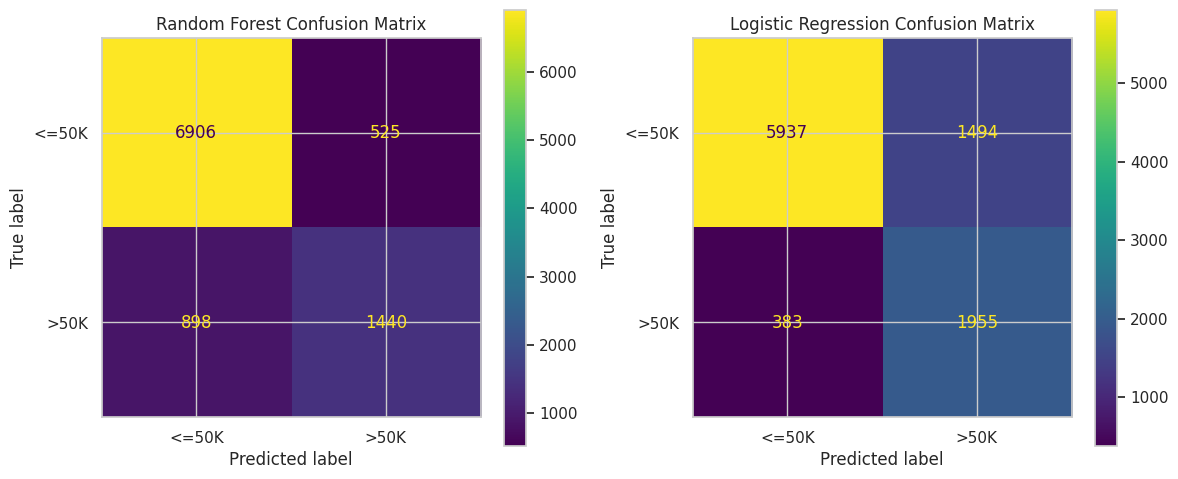

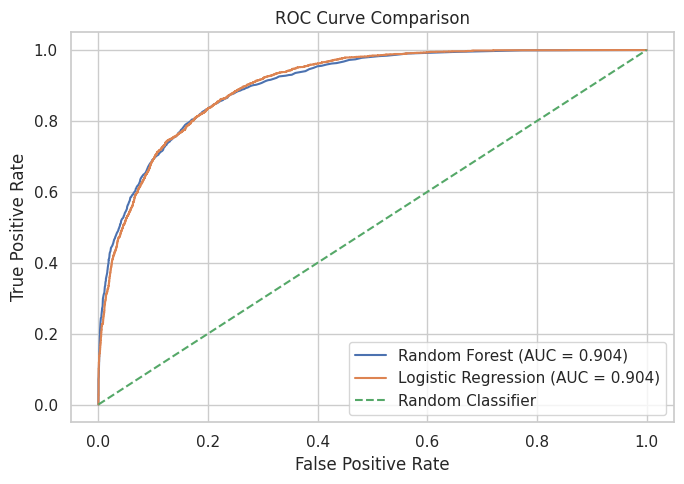

In [13]:
# ============================================================
# CELL 12 — Confusion matrices and ROC curves
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["<=50K", ">50K"]
).plot(ax=axes[0], values_format="d")

axes[0].set_title("Random Forest Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix=lr_cm,
    display_labels=["<=50K", ">50K"]
).plot(ax=axes[1], values_format="d")

axes[1].set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()


# ROC curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probabilities)

plt.figure(figsize=(7, 5))

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# CELL 13 — PART B, Q8 & Q9: Model comparison
# ============================================================

print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(metrics_df.round(4))

best_model_name = metrics_df.loc[
    metrics_df["F1-score"].idxmax(),
    "Model"
]

print("\nModel with highest F1-score:", best_model_name)

print("""
Black-box model selected for LIME: Random Forest

Reason:
Random Forest consists of many decision trees and combines their
predictions through an ensemble process. Its decision-making process
is therefore less directly interpretable than Logistic Regression,
whose coefficients provide a more straightforward global interpretation.

LIME is model-agnostic and can explain the Random Forest using only
its prediction function.
""")

BLACK_BOX_MODEL = rf_model

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Random Forest,0.8543,0.7328,0.6159,0.6693,0.9044
1,Logistic Regression,0.8079,0.5668,0.8362,0.6757,0.9044



Model with highest F1-score: Logistic Regression

Black-box model selected for LIME: Random Forest

Reason:
Random Forest consists of many decision trees and combines their
predictions through an ensemble process. Its decision-making process
is therefore less directly interpretable than Logistic Regression,
whose coefficients provide a more straightforward global interpretation.

LIME is model-agnostic and can explain the Random Forest using only
its prediction function.



In [15]:
# ============================================================
# CELL 14 — LIME prediction wrapper
# ============================================================

# Convert LIME integer-coded rows back into the original
# categorical strings before sending them through the model pipeline.

def lime_to_original_dataframe(lime_array):

    df = pd.DataFrame(
        lime_array,
        columns=lime_feature_names
    )

    # Convert categorical integer codes back to category names
    for col in categorical_features:

        col_index = lime_feature_names.index(col)
        categories = category_mappings[col]

        # Round because LIME categorical values are represented
        # by integer category codes.
        codes = np.rint(
            df.iloc[:, col_index].astype(float)
        ).astype(int)

        # Protect against unexpected values
        codes = np.clip(
            codes,
            0,
            len(categories) - 1
        )

        df[col] = [
            categories[int(code)]
            for code in codes
        ]

    return df


def lime_predict_proba(lime_array):

    original_df = lime_to_original_dataframe(lime_array)

    return BLACK_BOX_MODEL.predict_proba(original_df)


print("LIME prediction wrapper created successfully.")

LIME prediction wrapper created successfully.


In [16]:
# ============================================================
# CELL 15 — PART C, Q10 & Q11: Create LIME explainer
# ============================================================

X_lime_train_np = X_lime_train.to_numpy(dtype=float)

class_names = [
    "<=50K",
    ">50K"
]

explainer = LimeTabularExplainer(
    training_data=X_lime_train_np,
    feature_names=lime_feature_names,
    class_names=class_names,
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    mode="classification",
    discretize_continuous=True,
    random_state=SEED
)

print("LimeTabularExplainer created successfully!")

print("\nfeature_names:")
print(lime_feature_names)

print("\nclass_names:")
print(class_names)

print("\ncategorical_features:")
print(categorical_indices)

print("\ncategorical_names:")
print(
    {
        lime_feature_names[k]: v[:5]
        for k, v in list(categorical_names.items())[:5]
    }
)

LimeTabularExplainer created successfully!

feature_names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country']

class_names:
['<=50K', '>50K']

categorical_features:
[1, 3, 5, 6, 7, 8, 9, 13]

categorical_names:
{'workclass': ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc'], 'education': ['10th', '11th', '12th', '1st-4th', '5th-6th'], 'marital_status': ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married'], 'occupation': ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing'], 'relationship': ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried']}


In [17]:
# ============================================================
# CELL 16 — PART C, Q12: Select three test instances
# ============================================================

# Reset test indices for easier handling
X_test_reset = X_test.reset_index(drop=True)
y_test_array = np.array(y_test)

rf_test_prob = rf_model.predict_proba(X_test_reset)[:, 1]
rf_test_pred = rf_model.predict(X_test_reset)

# Find correct low-income prediction
correct_low = np.where(
    (rf_test_pred == 0) &
    (y_test_array == 0)
)[0]

# Find correct high-income prediction
correct_high = np.where(
    (rf_test_pred == 1) &
    (y_test_array == 1)
)[0]

# Find a prediction closest to decision boundary
boundary_index = np.argmin(
    np.abs(rf_test_prob - 0.5)
)

selected_indices = []

if len(correct_low) > 0:
    selected_indices.append(correct_low[0])

if len(correct_high) > 0:
    if correct_high[0] not in selected_indices:
        selected_indices.append(correct_high[0])

if boundary_index not in selected_indices:
    selected_indices.append(boundary_index)

# Ensure exactly 3
for i in range(len(X_test_reset)):
    if len(selected_indices) >= 3:
        break
    if i not in selected_indices:
        selected_indices.append(i)

selected_indices = selected_indices[:3]

print("Selected test instance indices:", selected_indices)

selection_table = pd.DataFrame({
    "Instance": selected_indices,
    "Actual Class": [
        "<=50K" if y_test_array[i] == 0 else ">50K"
        for i in selected_indices
    ],
    "Predicted Class": [
        "<=50K" if rf_test_pred[i] == 0 else ">50K"
        for i in selected_indices
    ],
    "P(>50K)": [
        rf_test_prob[i]
        for i in selected_indices
    ]
})

display(selection_table.round(4))

Selected test instance indices: [np.int64(0), np.int64(4), np.int64(711)]


,Instance,Actual Class,Predicted Class,P(>50K)
0,0,<=50K,<=50K,0.0
1,4,>50K,>50K,0.6
2,711,>50K,<=50K,0.5


In [18]:
# ============================================================
# CELL 17 — PART C, Q13-Q15: Generate LIME explanations
# ============================================================

def create_lime_explanation(
    instance_index,
    num_samples=5000,
    random_state=42
):

    lime_instance = X_lime_test.iloc[
        instance_index
    ].to_numpy(dtype=float)

    predicted_class = int(
        rf_test_pred[instance_index]
    )

    explanation = LimeTabularExplainer(
        training_data=X_lime_train_np,
        feature_names=lime_feature_names,
        class_names=class_names,
        categorical_features=categorical_indices,
        categorical_names=categorical_names,
        mode="classification",
        discretize_continuous=True,
        random_state=random_state
    ).explain_instance(
        lime_instance,
        lime_predict_proba,
        num_features=10,
        labels=(predicted_class,),
        num_samples=num_samples
    )

    return explanation


explanations = {}

for instance_number, idx in enumerate(
    selected_indices,
    start=1
):

    exp = create_lime_explanation(
        idx,
        num_samples=5000,
        random_state=SEED + instance_number
    )

    explanations[instance_number] = exp

    predicted_class = rf_test_pred[idx]

    print("\n" + "=" * 70)
    print(f"INSTANCE {instance_number} — TEST INDEX {idx}")
    print("=" * 70)

    print(
        "Actual class    :",
        class_names[y_test_array[idx]]
    )

    print(
        "Predicted class :",
        class_names[predicted_class]
    )

    print(
        "P(>50K)         :",
        f"{rf_test_prob[idx]:.4f}"
    )

    print("\nTop LIME contributions:")

    for feature, weight in exp.as_list(
        label=predicted_class
    ):
        direction = (
            "Positive → predicted class"
            if weight > 0
            else "Negative → against predicted class"
        )

        print(
            f"{feature:45s} "
            f"{weight:+.4f}   {direction}"
        )


INSTANCE 1 — TEST INDEX 0
Actual class    : <=50K
Predicted class : <=50K
P(>50K)         : 0.0000

Top LIME contributions:
capital_gain <= 0.00                          +0.4521   Positive → predicted class
marital_status=Never-married                  +0.0946   Positive → predicted class
capital_loss <= 0.00                          +0.0730   Positive → predicted class
hours_per_week <= 40.00                       +0.0722   Positive → predicted class
education_num <= 9.00                         +0.0694   Positive → predicted class
relationship=Own-child                        +0.0459   Positive → predicted class
sex=Male                                      -0.0309   Negative → against predicted class
education=HS-grad                             +0.0261   Positive → predicted class
occupation=Machine-op-inspct                  +0.0258   Positive → predicted class
race=White                                    -0.0133   Negative → against predicted class

INSTANCE 2 — TEST INDEX 4
Ac

In [19]:
# ============================================================
# CELL 18 — Important feature values
# ============================================================

for instance_number, idx in enumerate(
    selected_indices,
    start=1
):

    print("\n" + "=" * 70)
    print(f"INSTANCE {instance_number} — ACTUAL FEATURE VALUES")
    print("=" * 70)

    display(
        X_test_reset.iloc[
            [idx]
        ].T.rename(columns={idx: "Value"})
    )


INSTANCE 1 — ACTUAL FEATURE VALUES


,Value
age,30
workclass,Private
fnlwgt,378009
education,HS-grad
education_num,9
marital_status,Never-married
occupation,Machine-op-inspct
relationship,Own-child
race,White
sex,Male



INSTANCE 2 — ACTUAL FEATURE VALUES


,Value
age,42
workclass,Local-gov
fnlwgt,121012
education,Some-college
education_num,10
marital_status,Married-civ-spouse
occupation,Exec-managerial
relationship,Husband
race,White
sex,Male



INSTANCE 3 — ACTUAL FEATURE VALUES


,Value
age,29
workclass,Private
fnlwgt,337266
education,Assoc-voc
education_num,11
marital_status,Married-civ-spouse
occupation,Exec-managerial
relationship,Husband
race,White
sex,Male


In [21]:
# ============================================================
# CELL 18 — Important feature values
# ============================================================

for instance_number, idx in enumerate(
    selected_indices,
    start=1
):

    print("\n" + "=" * 70)
    print(f"INSTANCE {instance_number} — ACTUAL FEATURE VALUES")
    print("=" * 70)

    display(
        X_test_reset.iloc[
            [idx]
        ].T.rename(columns={idx: "Value"})
    )


INSTANCE 1 — ACTUAL FEATURE VALUES


,Value
age,30
workclass,Private
fnlwgt,378009
education,HS-grad
education_num,9
marital_status,Never-married
occupation,Machine-op-inspct
relationship,Own-child
race,White
sex,Male



INSTANCE 2 — ACTUAL FEATURE VALUES


,Value
age,42
workclass,Local-gov
fnlwgt,121012
education,Some-college
education_num,10
marital_status,Married-civ-spouse
occupation,Exec-managerial
relationship,Husband
race,White
sex,Male



INSTANCE 3 — ACTUAL FEATURE VALUES


,Value
age,29
workclass,Private
fnlwgt,337266
education,Assoc-voc
education_num,11
marital_status,Married-civ-spouse
occupation,Exec-managerial
relationship,Husband
race,White
sex,Male



LIME explanation for Instance 1


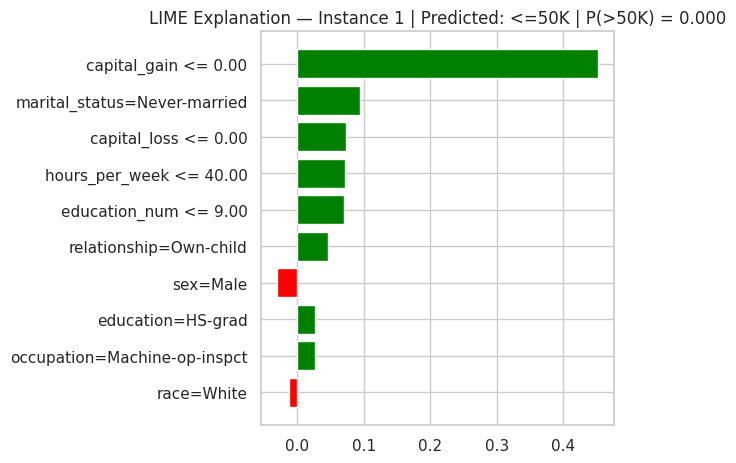


LIME explanation for Instance 2


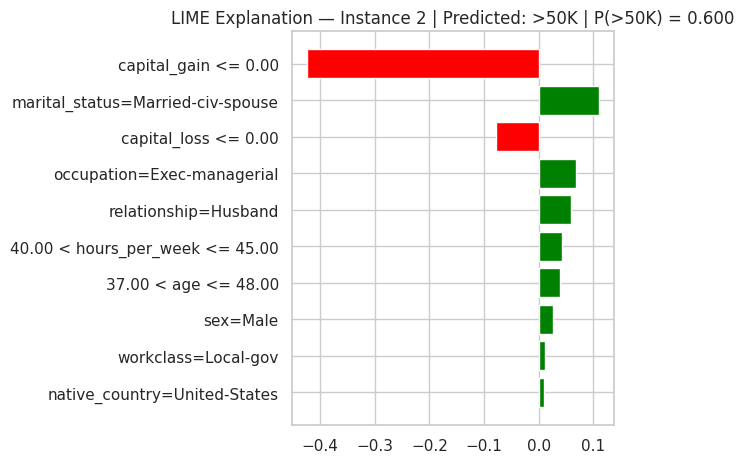


LIME explanation for Instance 3


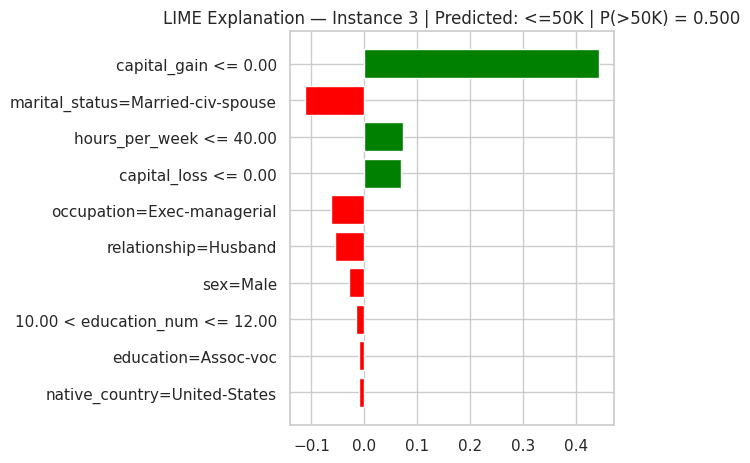

In [22]:
# ============================================================
# CELL 19 — Visual LIME explanations
# ============================================================

for instance_number, idx in enumerate(
    selected_indices,
    start=1
):

    predicted_class = int(
        rf_test_pred[idx]
    )

    exp = explanations[instance_number]

    print(
        f"\nLIME explanation for Instance {instance_number}"
    )

    fig = exp.as_pyplot_figure(
        label=predicted_class
    )

    plt.title(
        f"LIME Explanation — Instance {instance_number} | "
        f"Predicted: {class_names[predicted_class]} | "
        f"P(>50K) = {rf_test_prob[idx]:.3f}"
    )

    plt.tight_layout()
    plt.show()

In [23]:
# ============================================================
# CELL 20 — PART D, Q16 & Q17
# ============================================================

all_lime_results = {}

for instance_number, idx in enumerate(
    selected_indices,
    start=1
):

    predicted_class = int(
        rf_test_pred[idx]
    )

    exp = explanations[instance_number]

    lime_list = exp.as_list(
        label=predicted_class
    )

    positive = [
        item for item in lime_list
        if item[1] > 0
    ][:5]

    negative = [
        item for item in lime_list
        if item[1] < 0
    ]

    negative = sorted(
        negative,
        key=lambda x: abs(x[1]),
        reverse=True
    )[:5]

    all_lime_results[instance_number] = {
        "positive": positive,
        "negative": negative
    }

    print("\n" + "=" * 70)
    print(f"INSTANCE {instance_number}")
    print(
        f"Predicted class: {class_names[predicted_class]}"
    )
    print("=" * 70)

    print("\nTOP FIVE POSITIVE CONTRIBUTORS")

    for rank, (feature, weight) in enumerate(
        positive,
        start=1
    ):
        print(
            f"{rank}. {feature} | "
            f"LIME weight = {weight:+.4f}"
        )

    print("\nTOP FIVE NEGATIVE CONTRIBUTORS")

    for rank, (feature, weight) in enumerate(
        negative,
        start=1
    ):
        print(
            f"{rank}. {feature} | "
            f"LIME weight = {weight:+.4f}"
        )


INSTANCE 1
Predicted class: <=50K

TOP FIVE POSITIVE CONTRIBUTORS
1. capital_gain <= 0.00 | LIME weight = +0.4521
2. marital_status=Never-married | LIME weight = +0.0946
3. capital_loss <= 0.00 | LIME weight = +0.0730
4. hours_per_week <= 40.00 | LIME weight = +0.0722
5. education_num <= 9.00 | LIME weight = +0.0694

TOP FIVE NEGATIVE CONTRIBUTORS
1. sex=Male | LIME weight = -0.0309
2. race=White | LIME weight = -0.0133

INSTANCE 2
Predicted class: >50K

TOP FIVE POSITIVE CONTRIBUTORS
1. marital_status=Married-civ-spouse | LIME weight = +0.1112
2. occupation=Exec-managerial | LIME weight = +0.0688
3. relationship=Husband | LIME weight = +0.0588
4. 40.00 < hours_per_week <= 45.00 | LIME weight = +0.0426
5. 37.00 < age <= 48.00 | LIME weight = +0.0399

TOP FIVE NEGATIVE CONTRIBUTORS
1. capital_gain <= 0.00 | LIME weight = -0.4250
2. capital_loss <= 0.00 | LIME weight = -0.0774

INSTANCE 3
Predicted class: <=50K

TOP FIVE POSITIVE CONTRIBUTORS
1. capital_gain <= 0.00 | LIME weight = +0.4

In [24]:
# ============================================================
# CELL 21 — PART D, Q18: Interpret important features
# ============================================================

for instance_number, idx in enumerate(
    selected_indices,
    start=1
):

    predicted_class = int(
        rf_test_pred[idx]
    )

    print("\n" + "=" * 70)
    print(f"INTERPRETATION — INSTANCE {instance_number}")
    print("=" * 70)

    print(
        "Predicted class:",
        class_names[predicted_class]
    )

    print(
        "Prediction probability P(>50K):",
        f"{rf_test_prob[idx]:.4f}"
    )

    important = (
        all_lime_results[instance_number]["positive"]
        +
        all_lime_results[instance_number]["negative"]
    )

    print("\nFeature interpretation:")

    for feature_condition, weight in important:

        direction = (
            "supports the predicted class"
            if weight > 0
            else "opposes the predicted class"
        )

        print("\nFeature condition:", feature_condition)
        print("LIME weight:", round(weight, 4))
        print("Direction:", direction)
        print(
            "Effect:",
            "increases the local likelihood of the predicted class"
            if weight > 0
            else
            "reduces the local likelihood of the predicted class"
        )


INTERPRETATION — INSTANCE 1
Predicted class: <=50K
Prediction probability P(>50K): 0.0000

Feature interpretation:

Feature condition: capital_gain <= 0.00
LIME weight: 0.4521
Direction: supports the predicted class
Effect: increases the local likelihood of the predicted class

Feature condition: marital_status=Never-married
LIME weight: 0.0946
Direction: supports the predicted class
Effect: increases the local likelihood of the predicted class

Feature condition: capital_loss <= 0.00
LIME weight: 0.073
Direction: supports the predicted class
Effect: increases the local likelihood of the predicted class

Feature condition: hours_per_week <= 40.00
LIME weight: 0.0722
Direction: supports the predicted class
Effect: increases the local likelihood of the predicted class

Feature condition: education_num <= 9.00
LIME weight: 0.0694
Direction: supports the predicted class
Effect: increases the local likelihood of the predicted class

Feature condition: sex=Male
LIME weight: -0.0309
Directio

In [25]:
# ============================================================
# CELL 22 — PART D, Q19
# ============================================================

print("""
Q19 — Interpretation of a Positive LIME Weight
================================================

If LIME assigns a positive weight to:

    education = Bachelors

this means that, for the particular individual being explained,
the presence of the Bachelor's education category contributes
towards the class currently being explained by LIME.

If the predicted class is >50K, the positive weight means that
education = Bachelors supports the model's local prediction of
income above $50K.

If the predicted class is <=50K, the positive weight means that
education = Bachelors supports the model's local prediction of
income at or below $50K.

Therefore, a positive LIME weight does NOT universally mean
"high income". Its meaning depends on which class is being
explained.

The LIME weight represents a local contribution to the model's
prediction; it does not prove that education causes income to
increase.
""")


Q19 — Interpretation of a Positive LIME Weight

If LIME assigns a positive weight to:

    education = Bachelors

this means that, for the particular individual being explained,
the presence of the Bachelor's education category contributes
towards the class currently being explained by LIME.

If the predicted class is >50K, the positive weight means that
education = Bachelors supports the model's local prediction of
income above $50K.

If the predicted class is <=50K, the positive weight means that
education = Bachelors supports the model's local prediction of
income at or below $50K.

Therefore, a positive LIME weight does NOT universally mean
"high income". Its meaning depends on which class is being
explained.

The LIME weight represents a local contribution to the model's
prediction; it does not prove that education causes income to
increase.



In [26]:
# ============================================================
# CELL 23 — PART D, Q20
# ============================================================

comparison_table = pd.DataFrame({
    "Concept": [
        "Feature Importance",
        "LIME Weight",
        "Prediction Probability"
    ],
    "Meaning": [
        "Measures how important a feature is to the model overall.",
        "Measures how a feature condition contributes to one specific local prediction.",
        "Measures the model's estimated probability for a class."
    ],
    "Scope": [
        "Usually global",
        "Local / individual instance",
        "Individual prediction"
    ],
    "Example": [
        "Age may be highly important across the dataset.",
        "For one person, age > 35 may push the prediction toward >50K.",
        "The model may predict P(>50K) = 0.82."
    ]
})

display(comparison_table)

print("""
Key distinction:

Feature importance asks:
"Which features matter to the model overall?"

LIME weight asks:
"Which feature conditions influenced THIS prediction?"

Prediction probability asks:
"How confident is the model in the predicted class?"

These three quantities should not be treated as interchangeable.
""")

,Concept,Meaning,Scope,Example
0,Feature Importance,Measures how important a feature is to the mod...,Usually global,Age may be highly important across the dataset.
1,LIME Weight,Measures how a feature condition contributes t...,Local / individual instance,"For one person, age > 35 may push the predicti..."
2,Prediction Probability,Measures the model's estimated probability for...,Individual prediction,The model may predict P(>50K) = 0.82.



Key distinction:

Feature importance asks:
"Which features matter to the model overall?"

LIME weight asks:
"Which feature conditions influenced THIS prediction?"

Prediction probability asks:
"How confident is the model in the predicted class?"

These three quantities should not be treated as interchangeable.



In [27]:
# ============================================================
# CELL 24 — PART D, Q21: IF-THEN style explanation
# ============================================================

instance_number = 1
idx = selected_indices[instance_number - 1]

predicted_class = int(
    rf_test_pred[idx]
)

lime_list = explanations[
    instance_number
].as_list(
    label=predicted_class
)

# Take the strongest 5 contributions by absolute weight
strongest = sorted(
    lime_list,
    key=lambda x: abs(x[1]),
    reverse=True
)[:5]

print("=" * 70)
print("IF–THEN STYLE LIME EXPLANATION")
print("=" * 70)

print(
    f"Predicted class: {class_names[predicted_class]}"
)

print(
    f"P(>50K): {rf_test_prob[idx]:.4f}\n"
)

print("IF the following conditions hold:")

for feature, weight in strongest:
    print(
        f"  • {feature} "
        f"(LIME weight = {weight:+.4f})"
    )

print(
    "\nTHEN the combination of these local feature conditions "
    f"contributes to the model predicting {class_names[predicted_class]}."
)

print("""
Note: This is a local model explanation. It describes how the
model's decision is influenced by the feature conditions for this
specific individual; it does not establish causal relationships.
""")

IF–THEN STYLE LIME EXPLANATION
Predicted class: <=50K
P(>50K): 0.0000

IF the following conditions hold:
  • capital_gain <= 0.00 (LIME weight = +0.4521)
  • marital_status=Never-married (LIME weight = +0.0946)
  • capital_loss <= 0.00 (LIME weight = +0.0730)
  • hours_per_week <= 40.00 (LIME weight = +0.0722)
  • education_num <= 9.00 (LIME weight = +0.0694)

THEN the combination of these local feature conditions contributes to the model predicting <=50K.

Note: This is a local model explanation. It describes how the
model's decision is influenced by the feature conditions for this
specific individual; it does not establish causal relationships.



In [28]:
# ============================================================
# CELL 25 — PART E, Q22: Misclassification analysis
# ============================================================

incorrect_indices = np.where(
    rf_test_pred != y_test_array
)[0]

print(
    "Number of incorrectly classified test instances:",
    len(incorrect_indices)
)

if len(incorrect_indices) == 0:
    raise ValueError(
        "No misclassified instances were found. "
        "Try changing the Random Forest settings."
    )

# Select the first incorrect instance
mis_idx = int(incorrect_indices[0])

actual_class = int(
    y_test_array[mis_idx]
)

predicted_class = int(
    rf_test_pred[mis_idx]
)

prediction_probability = rf_test_prob[mis_idx]

print("\n" + "=" * 70)
print("SELECTED MISCLASSIFIED INSTANCE")
print("=" * 70)

print("Test index          :", mis_idx)
print("Actual class        :", class_names[actual_class])
print("Predicted class     :", class_names[predicted_class])
print("P(>50K)             :", round(prediction_probability, 4))

print("\nFeature values:")

display(
    X_test_reset.iloc[
        [mis_idx]
    ].T.rename(columns={mis_idx: "Value"})
)

Number of incorrectly classified test instances: 1423

SELECTED MISCLASSIFIED INSTANCE
Test index          : 8
Actual class        : >50K
Predicted class     : <=50K
P(>50K)             : 0.1867

Feature values:


,Value
age,29
workclass,Private
fnlwgt,200928
education,HS-grad
education_num,9
marital_status,Married-civ-spouse
occupation,Exec-managerial
relationship,Husband
race,White
sex,Male


In [29]:
# ============================================================
# CELL 26 — PART E, Q23 & Q24
# ============================================================

mis_explanation = create_lime_explanation(
    mis_idx,
    num_samples=5000,
    random_state=12345
)

mis_lime_list = mis_explanation.as_list(
    label=predicted_class
)

print("=" * 70)
print("LIME EXPLANATION OF MISCLASSIFICATION")
print("=" * 70)

for feature, weight in mis_lime_list:

    direction = (
        "POSITIVE — supports predicted class"
        if weight > 0
        else
        "NEGATIVE — opposes predicted class"
    )

    print(
        f"{feature:50s} "
        f"{weight:+.4f}   {direction}"
    )

positive_error = [
    x for x in mis_lime_list
    if x[1] > 0
]

negative_error = [
    x for x in mis_lime_list
    if x[1] < 0
]

positive_error = sorted(
    positive_error,
    key=lambda x: abs(x[1]),
    reverse=True
)[:5]

negative_error = sorted(
    negative_error,
    key=lambda x: abs(x[1]),
    reverse=True
)[:5]

print("\nTOP POSITIVE CONTRIBUTORS TO INCORRECT PREDICTION")

for feature, weight in positive_error:
    print(
        f"{feature} | {weight:+.4f}"
    )

print("\nTOP NEGATIVE CONTRIBUTORS TO INCORRECT PREDICTION")

for feature, weight in negative_error:
    print(
        f"{feature} | {weight:+.4f}"
    )

LIME EXPLANATION OF MISCLASSIFICATION
capital_gain <= 0.00                               +0.4459   POSITIVE — supports predicted class
marital_status=Married-civ-spouse                  -0.1126   NEGATIVE — opposes predicted class
hours_per_week <= 40.00                            +0.0721   POSITIVE — supports predicted class
education_num <= 9.00                              +0.0673   POSITIVE — supports predicted class
capital_loss <= 0.00                               +0.0636   POSITIVE — supports predicted class
occupation=Exec-managerial                         -0.0625   NEGATIVE — opposes predicted class
relationship=Husband                               -0.0564   NEGATIVE — opposes predicted class
sex=Male                                           -0.0277   NEGATIVE — opposes predicted class
education=HS-grad                                  +0.0275   POSITIVE — supports predicted class
race=White                                         -0.0137   NEGATIVE — opposes predicted cla

In [30]:
# ============================================================
# CELL 27 — PART E, Q25: Analyze model error
# ============================================================

distance_from_boundary = abs(
    prediction_probability - 0.5
)

print("=" * 70)
print("MODEL ERROR ANALYSIS")
print("=" * 70)

print(
    f"Actual class: {class_names[actual_class]}"
)

print(
    f"Predicted class: {class_names[predicted_class]}"
)

print(
    f"P(>50K): {prediction_probability:.4f}"
)

print(
    f"Distance from 0.50 decision boundary: "
    f"{distance_from_boundary:.4f}"
)

if distance_from_boundary < 0.10:
    boundary_comment = (
        "The prediction is relatively close to the decision boundary, "
        "so the model has weaker separation between the two classes."
    )
else:
    boundary_comment = (
        "The prediction is not extremely close to the decision boundary, "
        "suggesting that the model made a relatively confident prediction "
        "even though it was incorrect."
    )

print("\nBoundary interpretation:")
print(boundary_comment)

print("""
The LIME explanation can provide a possible model-level reason for
the error by showing which local feature conditions pushed the model
toward the incorrect class.

Positive contributors supported the predicted class, while negative
contributors opposed it. If strong contributions exist in both
directions, this indicates conflicting evidence in the individual's
feature profile.

LIME does not establish that these features caused the real-world
income outcome. It explains the behaviour of the trained model.
""")

MODEL ERROR ANALYSIS
Actual class: >50K
Predicted class: <=50K
P(>50K): 0.1867
Distance from 0.50 decision boundary: 0.3133

Boundary interpretation:
The prediction is not extremely close to the decision boundary, suggesting that the model made a relatively confident prediction even though it was incorrect.

The LIME explanation can provide a possible model-level reason for
the error by showing which local feature conditions pushed the model
toward the incorrect class.

Positive contributors supported the predicted class, while negative
contributors opposed it. If strong contributions exist in both
directions, this indicates conflicting evidence in the individual's
feature profile.

LIME does not establish that these features caused the real-world
income outcome. It explains the behaviour of the trained model.



In [31]:
# ============================================================
# CELL 28 — PART E, Q26: Causation
# ============================================================

print("""
Q26 — Can LIME Prove Causation?
================================

No. LIME cannot prove that a particular feature caused the model to
make an error.

MODEL ASSOCIATION:
A feature may be associated with a model prediction because the model
has learned patterns involving that feature.

FEATURE CONTRIBUTION:
A LIME weight indicates that a particular feature condition contributed
to the model's local prediction for the selected instance.

CAUSAL RELATIONSHIP:
A causal relationship means that changing the feature would actually
cause a change in the real-world outcome, under an appropriate causal
framework.

LIME only provides a local explanation of model behaviour. Therefore,
a large positive or negative LIME weight should not be interpreted as
proof of causation.

For example, if education = Bachelors has a positive LIME weight, this
means the condition contributed toward the model's prediction for that
individual. It does not prove that obtaining a Bachelor's degree would
cause the person's income to cross the income threshold.
""")


Q26 — Can LIME Prove Causation?

No. LIME cannot prove that a particular feature caused the model to
make an error.

MODEL ASSOCIATION:
A feature may be associated with a model prediction because the model
has learned patterns involving that feature.

FEATURE CONTRIBUTION:
A LIME weight indicates that a particular feature condition contributed
to the model's local prediction for the selected instance.

CAUSAL RELATIONSHIP:
A causal relationship means that changing the feature would actually
cause a change in the real-world outcome, under an appropriate causal
framework.

LIME only provides a local explanation of model behaviour. Therefore,
a large positive or negative LIME weight should not be interpreted as
proof of causation.

For example, if education = Bachelors has a positive LIME weight, this
means the condition contributed toward the model's prediction for that
individual. It does not prove that obtaining a Bachelor's degree would
cause the person's income to cross the income t

In [32]:
# ============================================================
# CELL 29 — PART F, Q27: Run LIME 10 times
# ============================================================

# Use the first selected instance for stability analysis
stability_idx = selected_indices[0]

stability_instance = (
    X_lime_test.iloc[
        stability_idx
    ].to_numpy(dtype=float)
)

stability_predicted_class = int(
    rf_test_pred[stability_idx]
)

print("=" * 70)
print("LIME STABILITY EXPERIMENT")
print("=" * 70)

print("Selected test index:", stability_idx)

print(
    "Actual class:",
    class_names[y_test_array[stability_idx]]
)

print(
    "Predicted class:",
    class_names[stability_predicted_class]
)

print(
    "P(>50K):",
    round(rf_test_prob[stability_idx], 4)
)

N_RUNS = 10
STABILITY_SAMPLES = 5000

stability_explanations = []

for run in range(N_RUNS):

    stability_explainer = LimeTabularExplainer(
        training_data=X_lime_train_np,
        feature_names=lime_feature_names,
        class_names=class_names,
        categorical_features=categorical_indices,
        categorical_names=categorical_names,
        mode="classification",
        discretize_continuous=True,
        random_state=1000 + run
    )

    exp = stability_explainer.explain_instance(
        stability_instance,
        lime_predict_proba,
        num_features=10,
        labels=(stability_predicted_class,),
        num_samples=STABILITY_SAMPLES
    )

    stability_explanations.append(exp)

    print(f"Run {run + 1}/10 completed.")

LIME STABILITY EXPERIMENT
Selected test index: 0
Actual class: <=50K
Predicted class: <=50K
P(>50K): 0.0
Run 1/10 completed.
Run 2/10 completed.
Run 3/10 completed.
Run 4/10 completed.
Run 5/10 completed.
Run 6/10 completed.
Run 7/10 completed.
Run 8/10 completed.
Run 9/10 completed.
Run 10/10 completed.


In [33]:
# ============================================================
# CELL 30 — PART F, Q28: Top five LIME weights
# ============================================================

stability_rows = []

for run_number, exp in enumerate(
    stability_explanations,
    start=1
):

    explanation_list = exp.as_list(
        label=stability_predicted_class
    )

    # Sort by absolute contribution
    top_five = sorted(
        explanation_list,
        key=lambda x: abs(x[1]),
        reverse=True
    )[:5]

    row = {
        "Run": run_number
    }

    for feature_number, (feature, weight) in enumerate(
        top_five,
        start=1
    ):
        row[f"Feature {feature_number}"] = (
            f"{feature} ({weight:+.4f})"
        )

    stability_rows.append(row)

stability_top5_table = pd.DataFrame(
    stability_rows
)

print("=" * 70)
print("TOP FIVE LIME FEATURES FOR EACH RUN")
print("=" * 70)

display(stability_top5_table)

TOP FIVE LIME FEATURES FOR EACH RUN


,Run,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5
0,1,capital_gain <= 0.00 (+0.4421),marital_status=Never-married (+0.0976),hours_per_week <= 40.00 (+0.0738),capital_loss <= 0.00 (+0.0659),education_num <= 9.00 (+0.0638)
1,2,capital_gain <= 0.00 (+0.4272),marital_status=Never-married (+0.0915),hours_per_week <= 40.00 (+0.0723),capital_loss <= 0.00 (+0.0701),education_num <= 9.00 (+0.0632)
2,3,capital_gain <= 0.00 (+0.4519),marital_status=Never-married (+0.0949),hours_per_week <= 40.00 (+0.0769),education_num <= 9.00 (+0.0682),capital_loss <= 0.00 (+0.0641)
3,4,capital_gain <= 0.00 (+0.4525),marital_status=Never-married (+0.0902),capital_loss <= 0.00 (+0.0784),hours_per_week <= 40.00 (+0.0749),education_num <= 9.00 (+0.0606)
4,5,capital_gain <= 0.00 (+0.4373),marital_status=Never-married (+0.0975),hours_per_week <= 40.00 (+0.0723),education_num <= 9.00 (+0.0703),capital_loss <= 0.00 (+0.0628)
5,6,capital_gain <= 0.00 (+0.4337),marital_status=Never-married (+0.0926),capital_loss <= 0.00 (+0.0821),hours_per_week <= 40.00 (+0.0753),education_num <= 9.00 (+0.0746)
6,7,capital_gain <= 0.00 (+0.4440),marital_status=Never-married (+0.0892),hours_per_week <= 40.00 (+0.0745),education_num <= 9.00 (+0.0729),capital_loss <= 0.00 (+0.0558)
7,8,capital_gain <= 0.00 (+0.4533),marital_status=Never-married (+0.0947),hours_per_week <= 40.00 (+0.0733),capital_loss <= 0.00 (+0.0686),education_num <= 9.00 (+0.0658)
8,9,capital_gain <= 0.00 (+0.4282),marital_status=Never-married (+0.0931),capital_loss <= 0.00 (+0.0762),hours_per_week <= 40.00 (+0.0751),education_num <= 9.00 (+0.0650)
9,10,capital_gain <= 0.00 (+0.4342),marital_status=Never-married (+0.0979),education_num <= 9.00 (+0.0720),hours_per_week <= 40.00 (+0.0701),capital_loss <= 0.00 (+0.0694)


In [34]:
# ============================================================
# CELL 31 — PART F, Q29: Stability statistics
# ============================================================

# Create a feature-by-run weight table.
# Missing features in a run are represented by 0.

all_features = sorted(
    set(
        feature
        for exp in stability_explanations
        for feature, weight in exp.as_list(
            label=stability_predicted_class
        )
    )
)

weight_matrix = pd.DataFrame(
    0.0,
    index=range(1, N_RUNS + 1),
    columns=all_features
)

for run_number, exp in enumerate(
    stability_explanations,
    start=1
):

    for feature, weight in exp.as_list(
        label=stability_predicted_class
    ):

        weight_matrix.loc[
            run_number,
            feature
        ] = weight


# Statistics
stability_summary = pd.DataFrame({
    "Mean LIME Weight": weight_matrix.mean(),
    "Standard Deviation": weight_matrix.std(),
    "Minimum LIME Weight": weight_matrix.min(),
    "Maximum LIME Weight": weight_matrix.max(),
    "Top-5 Appearances": [
        sum(
            feature in [
                f for f, w in exp.as_list(
                    label=stability_predicted_class
                )
                if abs(w) > 0
            ][:5]
            for exp in stability_explanations
        )
        for feature in weight_matrix.columns
    ]
})

# Coefficient of variation
stability_summary["CV (%)"] = (
    stability_summary["Standard Deviation"].abs()
    /
    stability_summary["Mean LIME Weight"].abs().replace(
        0,
        np.nan
    )
    * 100
)

# Sort by absolute mean contribution
stability_summary = stability_summary.sort_values(
    "Mean LIME Weight",
    key=lambda x: x.abs(),
    ascending=False
)

print("=" * 70)
print("LIME STABILITY SUMMARY")
print("=" * 70)

display(
    stability_summary.round(4)
)

LIME STABILITY SUMMARY


,Mean LIME Weight,Standard Deviation,Minimum LIME Weight,Maximum LIME Weight,Top-5 Appearances,CV (%)
capital_gain <= 0.00,0.4404,0.0099,0.4272,0.4533,10,2.2420
marital_status=Never-married,0.0939,0.0031,0.0892,0.0979,10,3.3349
hours_per_week <= 40.00,0.0739,0.0019,0.0701,0.0769,10,2.6236
capital_loss <= 0.00,0.0693,0.0079,0.0558,0.0821,10,11.3641
education_num <= 9.00,0.0676,0.0047,0.0606,0.0746,10,6.9288
relationship=Own-child,0.0458,0.0024,0.0429,0.0504,0,5.3186
occupation=Machine-op-inspct,0.0290,0.0053,0.0212,0.0364,0,18.1335
sex=Male,-0.0283,0.0035,-0.0322,-0.0222,0,12.4503
education=HS-grad,0.0267,0.0030,0.0222,0.0312,0,11.3831
race=White,-0.0072,0.0066,-0.0154,0.0000,0,91.1905


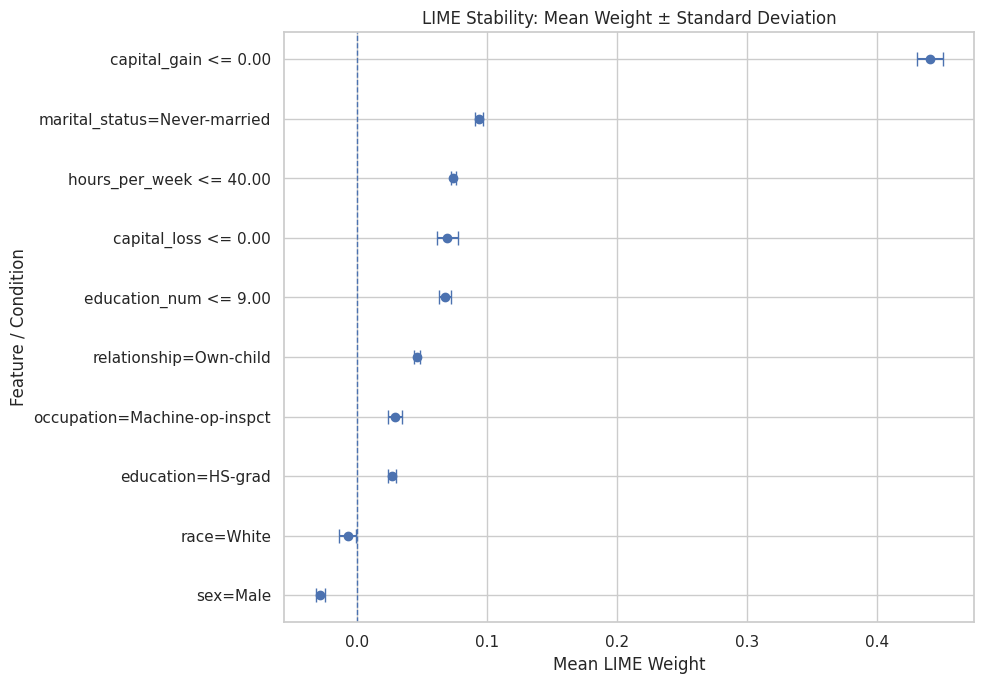

In [35]:
# ============================================================
# CELL 32 — PART F, Q30: Mean LIME Weight ± Standard Deviation
# ============================================================

# Show the 10 most important features by absolute mean weight
plot_data = (
    stability_summary
    .head(10)
    .sort_values("Mean LIME Weight")
)

plt.figure(figsize=(10, 7))

plt.errorbar(
    plot_data["Mean LIME Weight"],
    plot_data.index,
    xerr=plot_data["Standard Deviation"],
    fmt="o",
    capsize=5
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Mean LIME Weight")
plt.ylabel("Feature / Condition")
plt.title(
    "LIME Stability: Mean Weight ± Standard Deviation"
)

plt.tight_layout()
plt.show()

In [36]:
# ============================================================
# CELL 33 — PART F, Q31: Stable and unstable features
# ============================================================

# Only consider features that appeared at least once
appeared = stability_summary[
    stability_summary["Top-5 Appearances"] > 0
].copy()

# Most stable = lowest standard deviation
most_stable = appeared.sort_values(
    "Standard Deviation"
).iloc[0]

# Least stable = highest standard deviation
least_stable = appeared.sort_values(
    "Standard Deviation",
    ascending=False
).iloc[0]

# Highest average contribution by absolute mean
highest_average = appeared.loc[
    appeared["Mean LIME Weight"].abs().idxmax()
]

# Largest variation
largest_variation = appeared.loc[
    appeared["Standard Deviation"].idxmax()
]

print("=" * 70)
print("STABLE AND UNSTABLE FEATURES")
print("=" * 70)

print(
    "\n1. Most stable feature:"
)
print(
    most_stable.name,
    "| SD =",
    round(most_stable["Standard Deviation"], 4)
)

print(
    "\n2. Least stable feature:"
)
print(
    least_stable.name,
    "| SD =",
    round(least_stable["Standard Deviation"], 4)
)

print(
    "\n3. Feature with highest average contribution:"
)
print(
    highest_average.name,
    "| Mean =",
    round(highest_average["Mean LIME Weight"], 4)
)

print(
    "\n4. Feature with largest variation:"
)
print(
    largest_variation.name,
    "| SD =",
    round(largest_variation["Standard Deviation"], 4)
)

STABLE AND UNSTABLE FEATURES

1. Most stable feature:
hours_per_week <= 40.00 | SD = 0.0019

2. Least stable feature:
capital_gain <= 0.00 | SD = 0.0099

3. Feature with highest average contribution:
capital_gain <= 0.00 | Mean = 0.4404

4. Feature with largest variation:
capital_gain <= 0.00 | SD = 0.0099


In [37]:
# ============================================================
# CELL 34 — PART F, Q32: Why LIME varies
# ============================================================

print("""
Q32 — Why can LIME explanations vary between runs?
===================================================

1. RANDOM PERTURBATIONS
LIME generates perturbed samples around the selected instance.
Different random samples can lead to slightly different local
approximations.

2. NUMBER OF SAMPLES
A small number of perturbed samples provides less information about
the local model behaviour. Increasing num_samples generally gives
LIME more information from the local neighbourhood.

3. LOCAL NEIGHBOURHOOD
LIME focuses on observations near the instance being explained.
The characteristics of this neighbourhood influence the resulting
surrogate model.

4. KERNEL WIDTH
LIME gives different weights to perturbed observations according to
their proximity to the original instance. The kernel width controls
how quickly that influence decreases with distance.

5. MODEL COMPLEXITY
A complex model such as Random Forest can have nonlinear and
interaction effects. A simple local surrogate may approximate these
patterns differently depending on the sampled neighbourhood.

Therefore, some variation between LIME runs is expected. A stable
feature should generally maintain a similar contribution across
different runs, while unstable features may have large changes in
weight or may appear in the top features inconsistently.
""")


Q32 — Why can LIME explanations vary between runs?

1. RANDOM PERTURBATIONS
LIME generates perturbed samples around the selected instance.
Different random samples can lead to slightly different local
approximations.

2. NUMBER OF SAMPLES
A small number of perturbed samples provides less information about
the local model behaviour. Increasing num_samples generally gives
LIME more information from the local neighbourhood.

3. LOCAL NEIGHBOURHOOD
LIME focuses on observations near the instance being explained.
The characteristics of this neighbourhood influence the resulting
surrogate model.

4. KERNEL WIDTH
LIME gives different weights to perturbed observations according to
their proximity to the original instance. The kernel width controls
how quickly that influence decreases with distance.

5. MODEL COMPLEXITY
A complex model such as Random Forest can have nonlinear and
interaction effects. A simple local surrogate may approximate these
patterns differently depending on the sampled ne

In [38]:
# ============================================================
# CELL 35 — PART F, Q33 & Q34
# Compare num_samples = 1,000, 5,000, 10,000
# ============================================================

sample_sizes = [
    1000,
    5000,
    10000
]

NUM_REPEATS = 5

sample_size_results = []

for num_samples in sample_sizes:

    print(
        f"\nRunning stability experiment for "
        f"num_samples = {num_samples}"
    )

    experiment_weights = []

    for repeat in range(NUM_REPEATS):

        temp_explainer = LimeTabularExplainer(
            training_data=X_lime_train_np,
            feature_names=lime_feature_names,
            class_names=class_names,
            categorical_features=categorical_indices,
            categorical_names=categorical_names,
            mode="classification",
            discretize_continuous=True,
            random_state=5000 + num_samples + repeat
        )

        temp_exp = temp_explainer.explain_instance(
            stability_instance,
            lime_predict_proba,
            num_features=10,
            labels=(stability_predicted_class,),
            num_samples=num_samples
        )

        # Dictionary of all weights
        experiment_weights.append(
            dict(
                temp_exp.as_list(
                    label=stability_predicted_class
                )
            )
        )

        print(
            f"  Repeat {repeat + 1}/{NUM_REPEATS} complete"
        )

    temp_df = pd.DataFrame(
        experiment_weights
    ).fillna(0.0)

    # Calculate overall average SD
    mean_sd = temp_df.std().mean()

    # Average absolute weight variation
    mean_abs_weight = (
        temp_df.abs().mean().mean()
    )

    # Maximum standard deviation
    max_sd = temp_df.std().max()

    sample_size_results.append({
        "num_samples": num_samples,
        "Average Standard Deviation": mean_sd,
        "Maximum Standard Deviation": max_sd,
        "Average Absolute LIME Weight": mean_abs_weight
    })


sample_size_comparison = pd.DataFrame(
    sample_size_results
)

print("\n" + "=" * 70)
print("COMPARISON OF DIFFERENT num_samples VALUES")
print("=" * 70)

display(
    sample_size_comparison.round(4)
)


Running stability experiment for num_samples = 1000
  Repeat 1/5 complete
  Repeat 2/5 complete
  Repeat 3/5 complete
  Repeat 4/5 complete
  Repeat 5/5 complete

Running stability experiment for num_samples = 5000
  Repeat 1/5 complete
  Repeat 2/5 complete
  Repeat 3/5 complete
  Repeat 4/5 complete
  Repeat 5/5 complete

Running stability experiment for num_samples = 10000
  Repeat 1/5 complete
  Repeat 2/5 complete
  Repeat 3/5 complete
  Repeat 4/5 complete
  Repeat 5/5 complete

COMPARISON OF DIFFERENT num_samples VALUES


,num_samples,Average Standard Deviation,Maximum Standard Deviation,Average Absolute LIME Weight
0,1000,0.0094,0.0200,0.0721
1,5000,0.0052,0.0090,0.0731
2,10000,0.0037,0.0079,0.0737


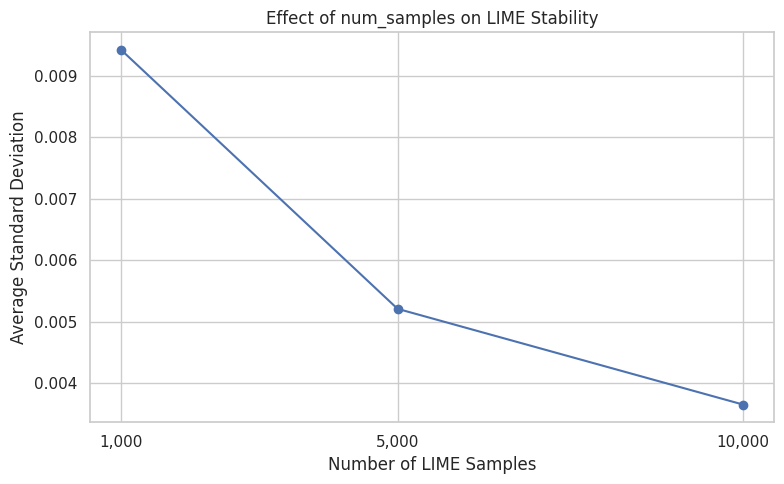


Interpretation:

The comparison above shows how the number of perturbed samples
affects the variation of LIME explanations.

Generally, increasing num_samples gives LIME more information about
the local neighbourhood and can reduce random variation. However,
the improvement is not necessarily perfectly monotonic for every
individual feature because LIME remains dependent on the sampled
local neighbourhood.



In [39]:
# ============================================================
# CELL 36 — Q34 visualization
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    sample_size_comparison["num_samples"],
    sample_size_comparison[
        "Average Standard Deviation"
    ],
    marker="o"
)

plt.xlabel("Number of LIME Samples")
plt.ylabel("Average Standard Deviation")
plt.title(
    "Effect of num_samples on LIME Stability"
)

plt.xticks(
    sample_sizes,
    ["1,000", "5,000", "10,000"]
)

plt.tight_layout()
plt.show()


print("""
Interpretation:

The comparison above shows how the number of perturbed samples
affects the variation of LIME explanations.

Generally, increasing num_samples gives LIME more information about
the local neighbourhood and can reduce random variation. However,
the improvement is not necessarily perfectly monotonic for every
individual feature because LIME remains dependent on the sampled
local neighbourhood.
""")

In [40]:
# ============================================================
# CELL 37 — FINAL ASSIGNMENT CHECKLIST
# ============================================================

checklist = pd.DataFrame({
    "Part": [
        "Part A",
        "Part A",
        "Part A",
        "Part A",
        "Part B",
        "Part B",
        "Part B",
        "Part B",
        "Part B",
        "Part C",
        "Part C",
        "Part C",
        "Part C",
        "Part D",
        "Part D",
        "Part D",
        "Part D",
        "Part D",
        "Part D",
        "Part E",
        "Part E",
        "Part E",
        "Part E",
        "Part E",
        "Part F",
        "Part F",
        "Part F",
        "Part F",
        "Part F",
        "Part F",
        "Part F",
        "Part F",
        "Part F",
        "Part F"
    ],
    "Question": list(range(1, 35)),
    "Requirement": [
        "Dataset information",
        "Data quality checks",
        "Preprocessing",
        "Categorical handling with LIME",
        "Stratified train/test split",
        "Train Random Forest and Logistic Regression",
        "Evaluate both models",
        "Compare model performance",
        "Select black-box model",
        "Create LimeTabularExplainer",
        "Specify LIME parameters",
        "Select three instances",
        "Generate LIME explanations",
        "Top five positive contributors",
        "Top five negative contributors",
        "Interpret important features",
        "Positive LIME weight interpretation",
        "Feature importance vs LIME vs probability",
        "IF-THEN explanation",
        "Select misclassified instance",
        "Generate LIME explanation for error",
        "Main contributors to error",
        "Analyze model error",
        "Causation analysis",
        "Run LIME 10 times",
        "Record top five weights",
        "Calculate stability measures",
        "Visualize stability",
        "Stable/unstable features",
        "Explain LIME variation",
        "Increase num_samples",
        "Compare 1,000 samples",
        "Compare 5,000 samples",
        "Compare 10,000 samples"
    ]
})

display(checklist)

print("\n🎉 ASSIGNMENT CODE COMPLETE — QUESTIONS 1 TO 34")

,Part,Question,Requirement
0,Part A,1,Dataset information
1,Part A,2,Data quality checks
2,Part A,3,Preprocessing
3,Part A,4,Categorical handling with LIME
4,Part B,5,Stratified train/test split
5,Part B,6,Train Random Forest and Logistic Regression
6,Part B,7,Evaluate both models
7,Part B,8,Compare model performance
8,Part B,9,Select black-box model
9,Part C,10,Create LimeTabularExplainer



🎉 ASSIGNMENT CODE COMPLETE — QUESTIONS 1 TO 34
